In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

In [84]:
rng = np.random.default_rng(42)
n_train, n_test, p = 200, 200, 100
ks = np.arange(2, 83, 8)

def generate(n, A, rng):
    m = A.shape[1]
    Z = rng.standard_normal((n, m))
    eta = rng.standard_normal((n, p))
    eps = rng.standard_normal(n)
    X = Z @ A.T + eta                 # row i is A @ Z[i] + eta[i]
    Y = Z[:, 0] + Z[:, 1] + eps
    return X, Y                       # Z is not returned: latent, unavailable to the model

results = []
for m in [3, 30]:
    A = rng.uniform(-2, 2, (p, m))    # drawn once per setting, shared by train and test
    X_train, Y_train = generate(n_train, A, rng)
    X_test, Y_test = generate(n_test, A, rng)

    for k in ks:
        knn = KNeighborsRegressor(n_neighbors=k, metric="euclidean")
        knn.fit(X_train, Y_train)
        results.append({"m": m, "k": k,
                        "MSE": mean_squared_error(Y_test, knn.predict(X_test))})

mse_table = pd.DataFrame(results).pivot(index="k", columns="m", values="MSE")
mse_table.columns = [f"m = {m}" for m in mse_table.columns]
mse_table.index.name = "k"
print(mse_table.style.to_typst())

#table(
  columns: 3,
  [], [m = 3], [m = 30],
  [k], [], [],

  [2], [1.607918], [2.744826],
  [10], [1.256992], [2.377459],
  [18], [1.282546], [2.338385],
  [26], [1.340470], [2.360125],
  [34], [1.336491], [2.321141],
  [42], [1.392700], [2.385609],
  [50], [1.454743], [2.408691],
  [58], [1.487196], [2.444888],
  [66], [1.550414], [2.469684],
  [74], [1.617419], [2.484347],
  [82], [1.676908], [2.500779],
)


In [85]:
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
n_train, n_test, p = 200, 200, 100
ks = np.arange(2, 83, 8)
n_reps = 50

def generate(n, A, rng):
    m = A.shape[1]
    Z = rng.standard_normal((n, m))
    eta = rng.standard_normal((n, p))
    eps = rng.standard_normal(n)
    return Z @ A.T + eta, Z[:, 0] + Z[:, 1] + eps

results = []
for rep in range(n_reps):
    for m in [3, 30]:
        A = rng.uniform(-2, 2, (p, m))            # new A each repetition
        X_train, Y_train = generate(n_train, A, rng)
        X_test, Y_test = generate(n_test, A, rng)

        for k in ks:
            knn = KNeighborsRegressor(n_neighbors=k, metric="euclidean")
            knn.fit(X_train, Y_train)
            results.append({"rep": rep, "m": m, "k": k,
                            "MSE": mean_squared_error(Y_test, knn.predict(X_test))})

sim = pd.DataFrame(results)
summary = sim.groupby(["m", "k"])["MSE"].agg(["mean", "std"])
summary["se"] = summary["std"] / np.sqrt(n_reps)
avg_mse = summary["mean"].unstack("m")            # rows: k, columns: m

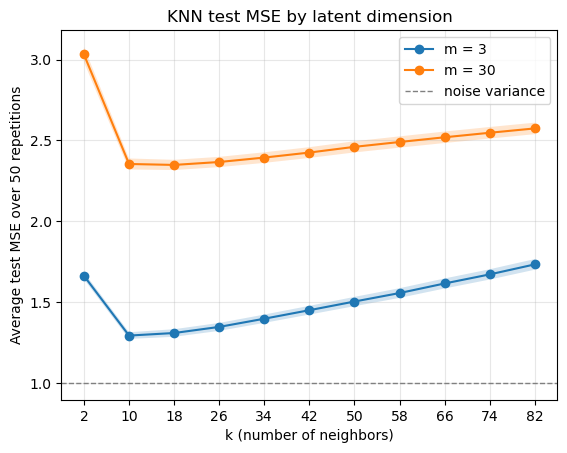

In [86]:
fig, ax = plt.subplots()
for m in [3, 30]:
    mean = summary.loc[m, "mean"]
    se = summary.loc[m, "se"]
    ax.plot(ks, mean, marker="o", label=f"m = {m}")
    ax.fill_between(ks, mean - se, mean + se, alpha=0.2)

ax.axhline(1, color="gray", ls="--", lw=1, label="noise variance")
ax.set_xlabel("k (number of neighbors)")
ax.set_ylabel(f"Average test MSE over {n_reps} repetitions")
ax.set_title("KNN test MSE by latent dimension")
ax.set_xticks(ks)
ax.grid(True, alpha=0.3)
ax.legend()
fig.savefig("knn_latent_mse.svg", bbox_inches="tight")
plt.show()